## Minimisation déterministe d'une fonction stochastique



On s'intéresse au problème
$$\min_{x  \in \mathbb{R}^{20}} f_1 (x) =\text{E} (\max_{i=1\dots m}|a_i^Tx-b_i |).$$
On suppose que $a_i$ est un vecteur colonne représentant la $i$eme ligne d'une matrice $A$ de taille $100 \times 20$, et les $b_i$ sont les coefficients d'un second membre $b$. Pour estimer la fonction $f_1$, ces quantités sont générées aleatoirement ($M$ i.i.d échantillons), donc on va generer une fois pour toutes à partir de distributions Gaussiennes de moyenne connue $\bar{A}$ et $\bar{b}$ et d'écart type identité, i.e. pour chaque $i$, $a_i$ ~ N( $\bar{a}_i$,  $\sigma^2 I$), $b_i$ ~ N( $\bar{b}_i$,  $\sigma^2 I$)

**Question :** Proposer deux fonctions d'évaluation de la fonction $f_1$ et d'un sous-gradient de $f_1$ basées sur des échantillons de taille $M$. Implementer et utiliser la fonction build_F1.


In [5]:
import Pkg
Pkg.add("JLD")
Pkg.add("Plots")
using JLD
using Plots

# moyenne des données
Abar = load("data2.jld")["Abar"]
bbar = load("data2.jld")["bbar"]

# Bruit et echantillon
m,n    = size(Abar)
M      = 1000;
sigma  = 4;

# Structure pour garder tous les M echantillons de A et b (une fois pour les restes)
struct F1samples
    A_noisy::Array{Float64, 3} # taille (M,m,n)
    b_noisy::Array{Float64, 3} # taille (M,m,1)
end

function build_F1(Abar,bbar,sigma,M)
    # Abar, bbar : moyenne des données, taille (m,n) et (m,1)
    # sigma : niveau de bruit
    # M: taille de l'échantillon
    m,n = size(Abar);
    A_noisy = zeros(M,m,n);
    b_noisy = zeros(M,m,1);
    
    for i in 1:M
        A_noisy[i,:,:] = Abar + sigma*randn(m,n);
        b_noisy[i,:,:] = bbar + sigma*randn(m,1);
    end
    
    
    f1 = F1samples(A_noisy,b_noisy);
    return f1
end

# Evaluation de f
function fvals(f1data::F1samples,x)
    # f1data: structure pour stoquer tous les M echantillons
    # x : vecteur courant
    # return f1(x)
    M = size(f1data.A_noisy,1);
    m = size(f1data.A_noisy,2);
    n = size(f1data.A_noisy,3);
    f1_tilde = 0.0;

    for j in 1:M
        Aj = f1data.A_noisy[j,:,:];
        bj = f1data.b_noisy[j,:,:];
        max = (Aj[1,:]'*x)[] - bj[1,1];
        for i in 2:m
            ri = (Aj[i,:]'*x)[] - bj[i,1];
            if abs(ri) > max
                max = ri;
            end
        end
        f1_tilde += abs(max);
    end
    f1_tilde = f1_tilde/M;
    return f1_tilde
end

# Evaluation d'un sous-gradient
function subgrads(f1data::F1samples,x)
    # f1: structure pour stoquer tous les données
    # x : vecteur courant
    # return subdrad de f1(x)
    
    M = size(f1data.A_noisy,1);
    m = size(f1data.A_noisy,2);
    n = size(f1data.A_noisy,3);
    subgrad = zeros(n,1);

    for j in 1:M
        Aj = f1data.A_noisy[j,:,:];
        bj = f1data.b_noisy[j,:,:];
        max = (Aj[1,:]'*x)[] - bj[1,1];
        i_max = 1;
        for i in 2:m
            ri = (Aj[i,:]'*x)[] - bj[i,1];
            if abs(ri) > max
                max = ri;
                i_max = i;
            end
        end
        subgrad += (Aj[i_max,:]*sign(max));
    end
    subgrad = subgrad./M;
    return subgrad
end

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.11/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.11/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.11/Manifest.toml`


subgrads (generic function with 1 method)

**Question :** Resoudre le problème $$ \min_x f_1(x)$$ en utilisant l'initialisation $x = 0$.  Prendre $M=1000$ échantillons et $\sigma=4$. Prendre un petit nombre d'iterations et choisir un bon pas de l'algorithme. **Afficher la courbre de convergence, et donner la valeur minimale de $f_1$ obtenue**

4.503429287780613


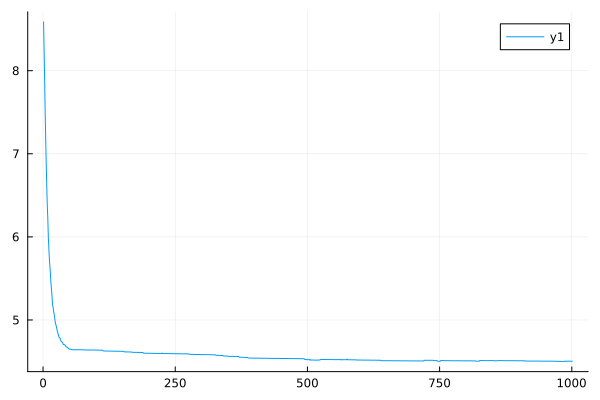

In [ ]:
x = zeros(n,1); i=0; lambda=1e-2;
choix_pas = 1; # 1 cas a, 2 cas b, 3 cas c
f1data = build_F1(Abar,bbar,sigma,M);
f = zeros(1001,1);
while i <= 1000
    i = i + 1;
    ## A compléter
    alpha = 10e-5
    x = x - alpha*subgrads(f1data,x);
    ## fin à compléter
    f[i] = fvals(f1data,x);
end
println(f[1001])
plot(f)

**Question :** Que se passe t-il si on initialise $x = 10$? Discuter l'effect de l'initialisation de $x$.

4.429904282578179


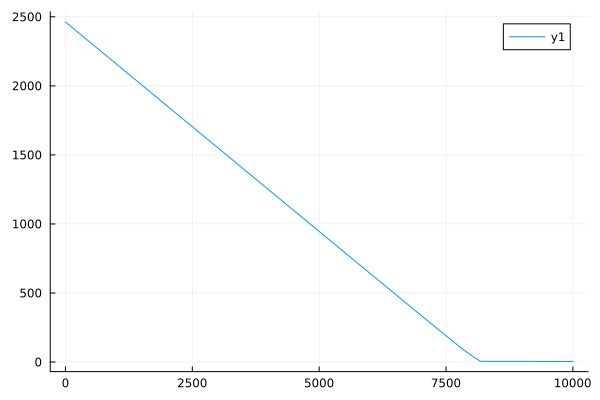

In [14]:
x = zeros(n,1).+10; i=0; lambda=1e-2;
choix_pas = 1; # 1 cas a, 2 cas b, 3 cas c
f1data = build_F1(Abar,bbar,sigma,M);
f = zeros(10001,1);
while i <= 10000
    i = i + 1;
    ## A compléter
    alpha = 10e-5
    x = x - alpha*subgrads(f1data,x);
    ## fin à compléter
    f[i] = fvals(f1data,x);
end
println(f[10001])
plot(f)